# Auswertung der RL-Experimente

Das Notebook liest die PyExperimenter-SQLite-Datenbank direkt ein. Es berücksichtigt nur abgeschlossene Runs und wertet Schrittverlauf, Episoden und Änderungserkennung aus.

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
ROLLING_WINDOW = 100
CONFIDENCE_Z = 1.96

In [2]:
project_candidates = (Path.cwd(), *Path.cwd().parents)
PROJECT_ROOT = next(
    (
        path
        for path in project_candidates
        if (path / "experiments" / "pyexperimenter_results.db").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "experiments/pyexperimenter_results.db wurde nicht gefunden"
    )

DATABASE_PATH = PROJECT_ROOT / "experiments" / "pyexperimenter_results.db"
print(f"Datenbank: {DATABASE_PATH}")

Datenbank: C:\Users\Merlin\Documents\Uni\Master\SoSe2026\Reinforcement Learning\exam_project\structural-change-dyna-q\experiments\pyexperimenter_results.db


In [14]:
with sqlite3.connect(DATABASE_PATH) as connection:
    runs = pd.read_sql_query(
        "SELECT * FROM structural_change_experiments",
        connection,
    )
    steps = pd.read_sql_query(
        """
        SELECT
            step.*,
            run.algorithm,
            run.environment,
            run.seed,
            run.change_step,
            run.change_duration
        FROM structural_change_experiments__steps AS step
        JOIN structural_change_experiments AS run
            ON run.ID = step.experiment_id
        WHERE run.status = 'done'
        """,
        connection,
    )
    episodes = pd.read_sql_query(
        """
        SELECT
            episode.*,
            run.algorithm,
            run.environment,
            run.seed,
            run.change_step,
            run.change_duration
        FROM structural_change_experiments__episodes AS episode
        JOIN structural_change_experiments AS run
            ON run.ID = episode.experiment_id
        WHERE run.status = 'done'
        """,
        connection,
    )

## Experimentstatus und Konfigurationen

In [12]:
environment = "transient-noise"

with sqlite3.connect(DATABASE_PATH) as connection:
    parameters = (environment,)

    connection.execute(
        """
        DELETE FROM structural_change_experiments__steps
        WHERE experiment_id IN (
            SELECT ID
            FROM structural_change_experiments
            WHERE environment = ?
        )
        """,
        parameters,
    )

    connection.execute(
        """
        DELETE FROM structural_change_experiments__episodes
        WHERE experiment_id IN (
            SELECT ID
            FROM structural_change_experiments
            WHERE environment = ?
        )
        """,
        parameters,
    )

    cursor = connection.execute(
        """
        DELETE FROM structural_change_experiments
        WHERE environment = ?
        """,
        parameters,
    )

print(f"{cursor.rowcount} Experimente gelöscht.")

0 Experimente gelöscht.


In [15]:
status_summary = (
    runs.groupby(["algorithm", "environment", "status"])
    .size()
    .rename("runs")
    .reset_index()
)
display(status_summary)

completed_configurations = (
    runs.loc[runs["status"] == "done"]
    .groupby(["algorithm", "environment"], as_index=False)
    .agg(
        completed_seeds=("seed", "nunique"),
        change_step=("change_step", "first"),
        change_duration=("change_duration", "first"),
    )
)
display(completed_configurations)

,algorithm,environment,status,runs
0,dyna-q,transient-noise,done,2
1,dyna-q-plus,transient-noise,done,2
2,q-learning,transient-noise,done,2
3,stability-aware-dyna-q,transient-noise,done,2


,algorithm,environment,completed_seeds,change_step,change_duration
0,dyna-q,transient-noise,2,1000,500
1,dyna-q-plus,transient-noise,2,1000,500
2,q-learning,transient-noise,2,1000,500
3,stability-aware-dyna-q,transient-noise,2,1000,500


## Rewardverlauf pro Schritt

Der kumulierte Reward sinkt bei überwiegend negativen Schritt-Rewards zwangsläufig. Deshalb wird hier der gleitende mittlere Reward pro Schritt gezeigt. Die Fläche ist das 95-%-Konfidenzintervall über die Seeds.

In [16]:
steps = steps.sort_values(["experiment_id", "global_step"]).copy()
steps["phase"] = np.select(
    [
        steps["global_step"] <= steps["change_step"],
        steps["global_step"] <= (
            steps["change_step"] + steps["change_duration"]
        ),
    ],
    ["before_change", "during_change"],
    default="after_change",
)
steps["rolling_reward"] = (
    steps.groupby("experiment_id")["reward"]
    .transform(
        lambda rewards: rewards.rolling(
            ROLLING_WINDOW,
            min_periods=max(1, ROLLING_WINDOW // 2),
        ).mean()
    )
)

step_curve = (
    steps.groupby(["algorithm", "environment", "global_step"])[
        "rolling_reward"
    ]
    .agg(["mean", "std", "count"])
    .reset_index()
)
step_curve["ci"] = (
    CONFIDENCE_Z
    * step_curve["std"].fillna(0.0)
    / np.sqrt(step_curve["count"])
)

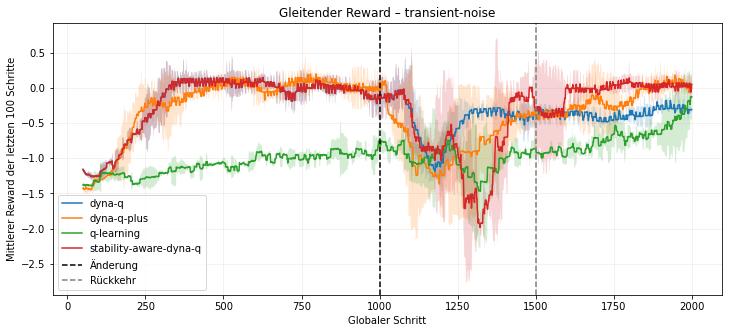

In [17]:
for environment, environment_curve in step_curve.groupby("environment"):
    figure, axis = plt.subplots(figsize=(12, 5))

    for algorithm, algorithm_curve in environment_curve.groupby("algorithm"):
        x = algorithm_curve["global_step"].to_numpy()
        mean = algorithm_curve["mean"].to_numpy()
        ci = algorithm_curve["ci"].to_numpy()
        axis.plot(x, mean, label=algorithm)
        axis.fill_between(x, mean - ci, mean + ci, alpha=0.2)

    environment_runs = runs.loc[
        (runs["environment"] == environment)
        & (runs["status"] == "done")
    ]
    change_step = int(environment_runs["change_step"].iloc[0])
    change_end = change_step + int(
        environment_runs["change_duration"].iloc[0]
    )
    axis.axvline(change_step, color="black", linestyle="--", label="Änderung")
    axis.axvline(change_end, color="grey", linestyle="--", label="Rückkehr")
    axis.set(
        title=f"Gleitender Reward – {environment}",
        xlabel="Globaler Schritt",
        ylabel=f"Mittlerer Reward der letzten {ROLLING_WINDOW} Schritte",
    )
    axis.legend()
    axis.grid(alpha=0.2)
    plt.show()

In [18]:
noise_phase = steps.merge(
    runs[["ID", "evidence_gain"]],
    left_on="experiment_id",
    right_on="ID",
)

noise_phase = noise_phase.loc[
    (noise_phase["environment"] == "transient-noise")
    & np.isclose(noise_phase["evidence_gain"], 0.01)
    & (noise_phase["global_step"] > 1000)
    & (noise_phase["global_step"] <= 1500)
]

variance_per_step = (
    noise_phase.groupby(["algorithm", "global_step"])
    ["rolling_reward"]
    .agg(
        mean_reward="mean",
        reward_variance="var",
        reward_std="std",
        seeds="count",
    )
    .reset_index()
)

stability_summary = (
    variance_per_step.groupby("algorithm")
    .agg(
        average_reward=("mean_reward", "mean"),
        average_variance=("reward_variance", "mean"),
        average_std=("reward_std", "mean"),
        worst_std=("reward_std", "max"),
        seeds=("seeds", "min"),
    )
    .sort_values("average_std")
)

display(stability_summary)

,average_reward,average_variance,average_std,worst_std,seeds
algorithm,,,,,
dyna-q,-0.46816,0.038471,0.158364,0.608112,2
q-learning,-1.01080,0.073694,0.217025,0.629325,2
stability-aware-dyna-q,-0.71955,0.160483,0.317986,1.081873,2
dyna-q-plus,-0.72874,0.189807,0.376294,0.841457,2


## Episodenmetriken

Episoden werden anhand ihres Endzeitpunkts einer Phase zugeordnet. Zuerst wird pro Seed gemittelt und anschließend über die Seeds, damit lange Runs mit vielen Episoden nicht automatisch stärker gewichtet werden.

In [7]:
episode_metrics = (
    steps.groupby(
        [
            "experiment_id",
            "algorithm",
            "environment",
            "seed",
            "episode",
            "change_step",
            "change_duration",
        ],
        as_index=False,
    )
    .agg(
        end_step=("global_step", "max"),
        episode_length=("global_step", "size"),
        episode_reward=("reward", "sum"),
    )
)
episode_metrics = episode_metrics.merge(
    episodes[["experiment_id", "episode", "end_reason"]],
    on=["experiment_id", "episode"],
    how="inner",
)
episode_metrics["phase"] = np.select(
    [
        episode_metrics["end_step"] <= episode_metrics["change_step"],
        episode_metrics["end_step"] <= (
            episode_metrics["change_step"]
            + episode_metrics["change_duration"]
        ),
    ],
    ["before_change", "during_change"],
    default="after_change",
)
episode_metrics["success"] = episode_metrics["end_reason"].eq("goal")

per_seed_phase = (
    episode_metrics.groupby(
        ["algorithm", "environment", "seed", "phase"],
        as_index=False,
    )
    .agg(
        episode_reward=("episode_reward", "mean"),
        episode_length=("episode_length", "mean"),
        success_rate=("success", "mean"),
        episodes=("episode", "count"),
    )
)
phase_summary = (
    per_seed_phase.groupby(["algorithm", "environment", "phase"], as_index=False)
    .agg(
        seeds=("seed", "nunique"),
        average_episode_reward=("episode_reward", "mean"),
        average_episode_length=("episode_length", "mean"),
        average_success_rate=("success_rate", "mean"),
    )
)
phase_order = ["before_change", "during_change", "after_change"]
phase_summary["phase"] = pd.Categorical(
    phase_summary["phase"],
    categories=phase_order,
    ordered=True,
)
display(phase_summary.sort_values(["environment", "algorithm", "phase"]))

,algorithm,environment,phase,seeds,average_episode_reward,average_episode_length,average_success_rate
1,dyna-q,transient-noise,before_change,2,-2.427361,11.909058,1.000000
2,dyna-q,transient-noise,during_change,2,-0.675206,10.474815,1.000000
0,dyna-q,transient-noise,after_change,2,0.037896,9.786765,0.980581
4,dyna-q-plus,transient-noise,before_change,2,-2.470819,11.843294,1.000000
5,dyna-q-plus,transient-noise,during_change,2,-0.261480,10.147321,1.000000
3,dyna-q-plus,transient-noise,after_change,2,-0.236991,9.885935,0.980581
7,q-learning,transient-noise,before_change,2,-46.565217,43.304348,0.913043
8,q-learning,transient-noise,during_change,2,-16.434783,22.209486,1.000000
6,q-learning,transient-noise,after_change,2,-1.293478,10.851295,0.989130
10,stability-aware-dyna-q,transient-noise,before_change,2,-2.427361,11.909058,1.000000


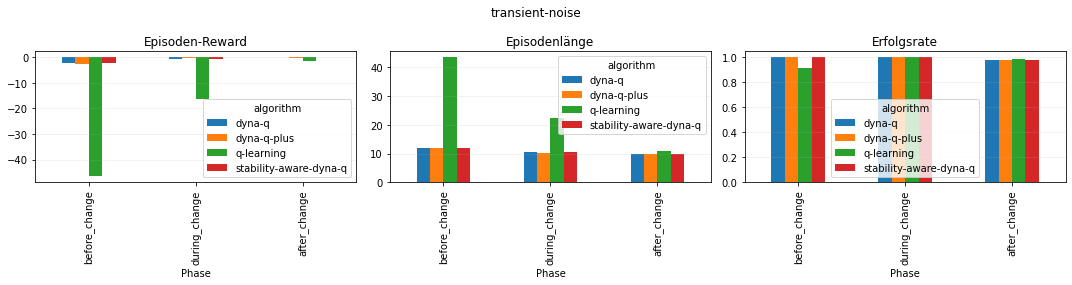

In [8]:
for environment, environment_metrics in phase_summary.groupby("environment", observed=True):
    figure, axes = plt.subplots(1, 3, figsize=(15, 4))
    metrics = [
        ("average_episode_reward", "Episoden-Reward"),
        ("average_episode_length", "Episodenlänge"),
        ("average_success_rate", "Erfolgsrate"),
    ]

    for axis, (metric, title) in zip(axes, metrics):
        pivot = environment_metrics.pivot(
            index="phase",
            columns="algorithm",
            values=metric,
        ).reindex(phase_order)
        pivot.plot(kind="bar", ax=axis)
        axis.set_title(title)
        axis.set_xlabel("Phase")
        axis.grid(axis="y", alpha=0.2)

    figure.suptitle(environment)
    figure.tight_layout()
    plt.show()

## Erkannte strukturelle Änderungen

Für Agenten ohne Änderungserkennung bleiben die Diagnosefelder leer. Beim Stability-Aware-Agenten werden Anzahl und Zeitpunkt bestätigter Reparaturen ausgewertet.

In [21]:
detector_steps = steps.dropna(subset=["change_detected"]).copy()

if detector_steps.empty:
    print("Noch keine abgeschlossenen Runs mit Änderungserkennung vorhanden.")
else:
    detections = detector_steps.loc[detector_steps["change_detected"].astype(bool)].copy()
    detections["delay_from_change"] = (
        detections["global_step"] - detections["change_step"]
    )
    detection_summary = (
        detections.groupby(["algorithm", "environment", "phase"], as_index=False)
        .agg(
            detections=("change_detected", "size"),
            seeds_with_detection=("seed", "nunique"),
            average_delay=("delay_from_change", "mean"),
            average_stability=("stability_score", "mean"),
            average_evidence=("change_evidence", "mean"),
        )
    )
    display(detection_summary)
    display(
        detections[[
            "experiment_id",
            "seed",
            "global_step",
            "phase",
            "stability_score",
            "change_evidence",
        ]]
    )

,algorithm,environment,phase,detections,seeds_with_detection,average_delay,average_stability,average_evidence
0,stability-aware-dyna-q,mixed-stability,after_change,8,7,785.000000,0.825000,2.912500
1,stability-aware-dyna-q,mixed-stability,before_change,21,13,-431.904762,0.633333,2.666667
2,stability-aware-dyna-q,mixed-stability,during_change,18,12,243.000000,0.894444,2.866667
3,stability-aware-dyna-q,shortcut,during_change,1,1,180.000000,0.900000,2.700000
4,stability-aware-dyna-q,two-routes,during_change,20,20,7.950000,1.000000,3.000000


,experiment_id,seed,global_step,phase,stability_score,change_evidence
45004,23,0,1005,during_change,1.0,3.0
51007,26,1,1008,during_change,1.0,3.0
57002,29,2,1003,during_change,1.0,3.0
63008,32,3,1009,during_change,1.0,3.0
69005,35,4,1006,during_change,1.0,3.0
...,...,...,...,...,...,...
462162,232,18,163,before_change,0.9,2.7
462895,232,18,896,before_change,0.5,2.5
463250,232,18,1251,during_change,0.7,2.8
479253,240,19,1254,during_change,1.0,3.0


## Interpretation

Für die finale Bewertung sollten pro Konfiguration alle 20 Seeds abgeschlossen sein. Relevant sind insbesondere:

- Einbruch von Reward und Erfolgsrate während der Änderung,
- Verbesserung nach der Änderung beziehungsweise nach der Rückkehr,
- Episodenlänge und Erfolgsrate je Phase,
- Verzögerung bis zur erkannten Änderung,
- Fehlalarme vor der eigentlichen Änderung.